In [1]:
import pandas as pd
import os
from unicodedata import normalize
import seaborn as sns

java_path = "D:\\jdk-22.0.2"
os.environ["JAVA_HOME"] = java_path

path = '..\\dados\\csv\\avaliacao_progov'


In [2]:
df = pd.read_parquet(os.path.join(path, 'avaliacao_progov_agrupado.parquet'))

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115862 entries, 0 to 1115861
Data columns (total 15 columns):
 #   Column                      Non-Null Count    Dtype   
---  ------                      --------------    -----   
 0   dsArea1                     1115862 non-null  object  
 1   notaFinalPonderada1         1115862 non-null  float64 
 2   dsQuestao1                  1115862 non-null  object  
 3   dsQuestao_Abrev1            1115862 non-null  object  
 4   notafinal_Questao1          1115862 non-null  float64 
 5   dsItemVerificacao1          1115862 non-null  object  
 6   dsItemVerificacao_Abrev1    1115862 non-null  object  
 7   notaFinal_ItemVerificacao1  1115862 non-null  float64 
 8   dsQuestaoAuxiliar1          1115862 non-null  object  
 9   notaFinal_QuestaoAuxiliar   1115756 non-null  float64 
 10  nmEntidadeVinculada         1115862 non-null  object  
 11  dsTipoResposta              1115862 non-null  object  
 12  id_municipio                1115862 non-nu

In [24]:
df.describe()

,anoAplicacao1,notaFinalPonderada1,notafinal_Questao1,notaFinal_ItemVerificacao1,notaFinal_QuestaoAuxiliar
count,1.115862e+06,1.115862e+06,1.115862e+06,1.115862e+06,1.115756e+06
mean,2.022510e+03,7.278217e+00,7.132961e+00,7.369857e+00,7.563006e+00
std,4.999068e-01,1.109448e+00,1.516404e+00,2.488457e+00,3.247995e+00
min,2.022000e+03,3.930000e+00,8.000000e-01,0.000000e+00,0.000000e+00
25%,2.022000e+03,6.460000e+00,6.200000e+00,5.900000e+00,6.200000e+00
50%,2.023000e+03,7.310000e+00,7.100000e+00,8.000000e+00,9.200000e+00
75%,2.023000e+03,8.090000e+00,8.300000e+00,9.600000e+00,1.000000e+01
max,2.023000e+03,9.760000e+00,1.000000e+01,1.000000e+01,1.000000e+01


<Axes: xlabel='notaFinal_ItemVerificacao1', ylabel='Count'>

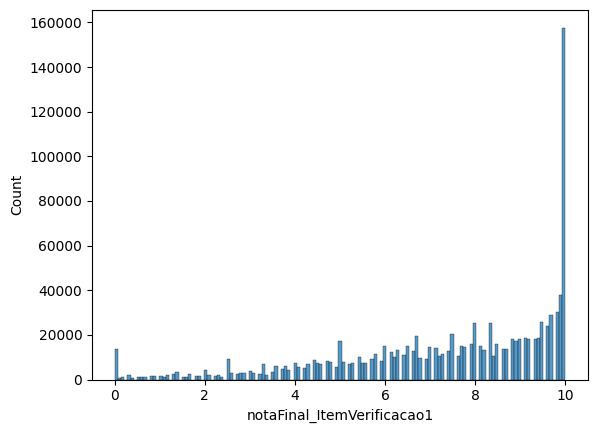

In [3]:
sns.histplot(df['notaFinal_ItemVerificacao1'])

<Axes: xlabel='notaFinalPonderada1', ylabel='Count'>

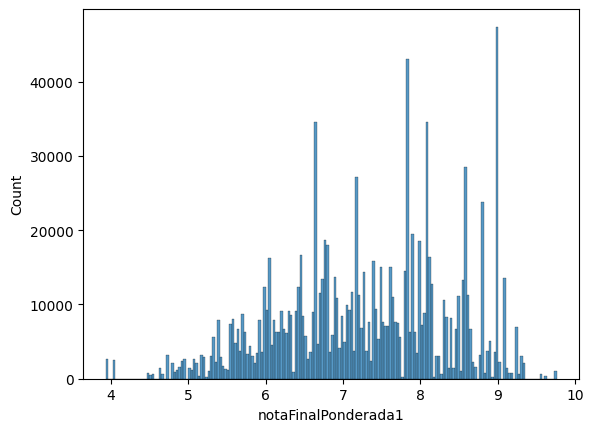

In [5]:
sns.histplot(df['notaFinalPonderada1'])


In [7]:
len(df.query('notaFinalPonderada1 < 5')['municipio'].unique())

22

<Axes: xlabel='notaFinal_ItemVerificacao1', ylabel='Count'>

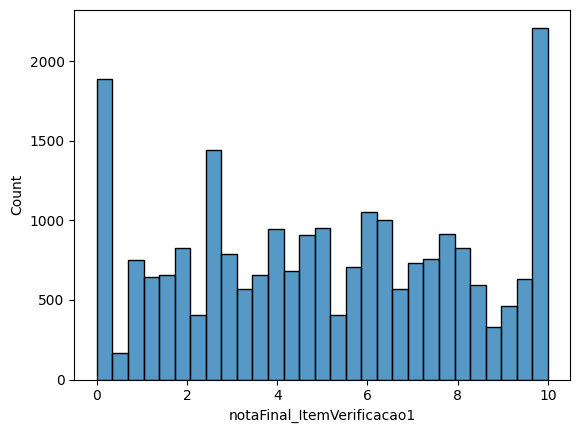

In [8]:
sns.histplot(df.query('notaFinalPonderada1 < 5')['notaFinal_ItemVerificacao1'])

In [9]:
df.query('notaFinalPonderada1 < 5')['notaFinal_ItemVerificacao1'].std()

3.0629681110055853

In [12]:
df.query('notaFinalPonderada1 < 5').query('notaFinal_ItemVerificacao1 <= 2')['dsQuestaoAuxiliar1'].unique()

array(['O Município dispõe de processo de trabalho instituído em norma (lei, decreto, instrução normativa etc.) para a realização de ações de identificação de crianças em idade escolar cujas famílias não buscaram a realização de matrícula na rede municipal de ensino (busca ativa da “demanda não manifesta”)?',
       'O Município dispõe de plano para expansão de vagas na educação infantil ou outro instrumento que estabeleça ações e metas de ampliação da oferta educacional visando ao atendimento da demanda manifesta por vagas na educação infantil atualmente não atendida?',
       'O Município propicia transparência à demanda manifesta por vagas na educação infantil por meio da disponibilização em seu site oficial, no mínimo, de informações atualizadas sobre a quantidade de alunos atendidos e a lista de espera por vagas em cada unidade educacional da rede municipal?',
       'O plano para expansão de vagas na educação infantil (ou outro instrumento com a mesma finalidade) está publicado n

In [57]:
len(df['dsQuestaoAuxiliar1'].unique())

362

In [15]:
df.groupby(['dsQuestaoAuxiliar1'])['notaFinal_ItemVerificacao1'].describe()

,count,mean,std,min,25%,50%,75%,max
dsQuestaoAuxiliar1,,,,,,,,
A Educação Alimentar e Nutricional está inserida de forma transversal no Currículo da escola?,3050.0,7.940787,1.569622,0.7,7.2,8.3,9.1,10.0
"A avaliação diagnóstica aplicada contemplou, no mínimo, os componentes curriculares de língua portuguesa e matemática?",399.0,6.507769,3.361609,0.0,4.0,8.0,10.0,10.0
"A carga de trabalho dos professores da unidade educacional prevê período reservado a estudos, planejamento e avaliação (carga horária para atividades pedagógicas extraclasse)?",5213.0,8.163476,1.503671,3.1,6.9,8.5,9.5,10.0
"A carga de trabalho dos professores da unidade educacional prevê período reservado a estudos, planejamento e avaliação?",5253.0,8.513192,1.650396,2.5,8.1,9.3,9.8,10.0
A demanda por profissionais de educação na rede municipal de ensino no ano de 2023 foi diagnosticada e documentada?,399.0,8.136842,1.378431,3.7,7.2,8.3,9.4,10.0
...,...,...,...,...,...,...,...,...
Todos os estudantes do ensino fundamental diagnosticados com baixo rendimento escolar no ano de 2023 foram atendidos em ações de reforço/recomposição de aprendizagem no contraturno?,3359.0,6.092974,2.572356,0.0,4.6,6.6,8.0,10.0
"Todos os professores da unidade educacional possuem formação específica de nível superior, obtida em curso de licenciatura na área de conhecimento em que atuam?",10483.0,8.856224,1.003782,5.0,8.4,9.0,9.7,10.0
"Todos os professores da unidade educacional possuem, no mínimo, ensino médio completo?",10483.0,8.856224,1.003782,5.0,8.4,9.0,9.7,10.0


In [4]:
len(df.query('notaFinal_ItemVerificacao1 <= 2')['dsQuestaoAuxiliar1'].unique())

295

In [30]:
df.query('notaFinal_ItemVerificacao1 <= 2')['dsQuestaoAuxiliar1'].value_counts()/(2*len(df['municipio'].unique()))


dsQuestaoAuxiliar1
O Município promoveu ações de acompanhamento da saúde vocal dos profissionais da educação da unidade educacional nos últimos 12 meses?                                                                                                                                                                                           5.090226
Os profissionais da educação da unidade educacional passaram por avaliações médicas promovidas pela gestão municipal, nos últimos 12 meses, com, no mínimo, a aferição da pressão arterial e exames de glicemia dos professores?                                                                                                 2.697995
Os profissionais da educação da unidade educacional têm acesso a atividades coletivas regulares que visem à melhoria da sua qualidade de vida, tais como terapia em grupo, educação física, meditação, caminhada, ginástica laboral etc.?                                                                                        

In [9]:
df['municipio'].value_counts()

municipio
95-CURITIBA            80335
277-PONTA GROSSA       29859
193-LONDRINA           25168
70-CASCAVEL            23127
211-MARINGÁ            21958
                       ...  
97-DIAMANTE D'OESTE      579
302-RENASCENÇA           572
126-GODOY MOREIRA        571
244-NOVO ITACOLOMI       565
369-SULINA               433
Name: count, Length: 399, dtype: int64

In [5]:
df['dsArea1'].value_counts()

dsArea1
Educação    2231724
Name: count, dtype: int64

In [6]:
df['anoAplicacao1'].value_counts()

anoAplicacao1
2023    568716
2022    547146
Name: count, dtype: int64

In [9]:
df.query('anoAplicacao1 == 2023')['dsQuestao_Abrev1'].value_counts()

dsQuestao_Abrev1
Instalações das unidades escolares     174700
Gestão de pessoas                      117971
Práticas pedagógicas                    71948
Equipamentos das unidades escolares     66958
Serviço de alimentação escolar          39874
Acesso e permanência                    38770
Instrumentos de planejamento            33067
Serviço de transporte escolar           25428
Name: count, dtype: int64

In [10]:
df.query('anoAplicacao1 == 2022')['dsQuestao_Abrev1'].value_counts()

dsQuestao_Abrev1
Instalações das unidades escolares     161587
Gestão de pessoas                      115823
Práticas pedagógicas                    73622
Equipamentos das unidades escolares     72302
Acesso e permanência                    48388
Instrumentos de planejamento            32648
Serviço de alimentação escolar          21757
Serviço de transporte escolar           21019
Name: count, dtype: int64

In [ ]:
df.query('anoAplicacao1 == 2022')['dsQuestao_Abrev1'].value_counts()

In [3]:
df2023 = df.query('anoAplicacao1 == 2023')
df2022 = df.query('anoAplicacao1 == 2022')

In [21]:
df2023['notaFinalPonderada1'].describe()

count    1.706148e+06
mean     7.509124e+00
std      1.165955e+00
min      3.930000e+00
25%      6.650000e+00
50%      7.590000e+00
75%      8.560000e+00
max      9.760000e+00
Name: notaFinalPonderada1, dtype: float64

In [34]:
df2023['nmEntidadeVinculada'].value_counts()

nmEntidadeVinculada
SECRETARIA MUNICIPAL DE EDUCAÇÃO              12958
SECRETARIA MUNICIPAL DE EDUCAÇÃO E CULTURA     5908
CRIANCA FELIZ C M E I                          2882
SECRETARIA MUNICIPAL DA EDUCAÇÃO               2615
PEQUENO PRINCIPE C M E I                       2457
                                              ...  
MARIA ALZIRA DE SOUZA TRINDADE C M E I           18
NOEMIA B CARNEIRO C M E I                        17
RECANTO FELIZ M MESSIAS C M E I                  17
CANTINHO DA SERRA C M E I                        16
MAMAE MARTA MARGARIDA C M E I                    15
Name: count, Length: 4753, dtype: int64

In [23]:
dfInsta2023 = df.query('dsQuestao_Abrev1 == "Instalações das unidades escolares"')


In [24]:
df.groupby(['municipio', 'anoAplicacao1'])['notaFinalPonderada1'].mean()

C:\Users\gvane\AppData\Local\Temp\ipykernel_26484\1319098706.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['municipio', 'anoAplicacao1'])['notaFinalPonderada1'].mean()


municipio           anoAplicacao1
1-ABATIÁ            2022             4.86
                    2023             4.66
10-ALVORADA DO SUL  2022             5.44
                    2023             7.71
100-DOIS VIZINHOS   2022             8.21
                                     ... 
VITORINO            2023             6.38
WENCESLAU BRAZ      2022             5.06
                    2023             5.55
XAMBRE              2022             6.06
                    2023             5.71
Name: notaFinalPonderada1, Length: 1596, dtype: float64

In [25]:
df.groupby(['municipio', 'anoAplicacao1'])['notaFinalPonderada1'].std().sum()

C:\Users\gvane\AppData\Local\Temp\ipykernel_26484\2834732137.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['municipio', 'anoAplicacao1'])['notaFinalPonderada1'].std().sum()


0.0

In [4]:
maiorNota2022 = df2022.query(f"notaFinalPonderada1 == {df2022['notaFinalPonderada1'].max()}")
menorNota2022 = df2022.query(f"notaFinalPonderada1 == {df2022['notaFinalPonderada1'].min()}")

maiorNota2023 = df2023.query(f"notaFinalPonderada1 == {df2023['notaFinalPonderada1'].max()}")
menorNota2023 = df2023.query(f"notaFinalPonderada1 == {df2023['notaFinalPonderada1'].min()}")


In [5]:
print('########### 2022')
print(maiorNota2022['municipio'].value_counts())
print('\n########### 2023')
print(maiorNota2023['municipio'].value_counts())

########### 2022
municipio
QUATRO PONTES         356
SAO CARLOS DO IVAI    289
Name: count, dtype: int64

########### 2023
municipio
SAO PEDRO DO IVAI    694
QUATRO PONTES        379
Name: count, dtype: int64


In [6]:
print('########### 2022')
print(menorNota2022['municipio'].value_counts())
print('\n########### 2023')
print(menorNota2023['municipio'].value_counts())

########### 2022
municipio
GUARAQUECABA    2571
Name: count, dtype: int64

########### 2023
municipio
GUARAQUECABA    2715
Name: count, dtype: int64


In [22]:
len(df['dsQuestaoAuxiliar1'].unique())

362

## Maior nota

In [17]:
qtPontes = df.query("municipio == 'QUATRO PONTES'")
qtPontes

,dsArea1,notaFinalPonderada1,dsQuestao1,dsQuestao_Abrev1,notafinal_Questao1,dsItemVerificacao1,dsItemVerificacao_Abrev1,notaFinal_ItemVerificacao1,dsQuestaoAuxiliar1,notaFinal_QuestaoAuxiliar,nmEntidadeVinculada,dsTipoResposta,id_municipio,municipio,anoAplicacao1
282126,Educação,9.29,O Município dispõe de instrumentos de planejam...,Instrumentos de planejamento,9.6,O Plano Municipal de Educação foi elaborado e ...,Plano Municipal de Educação (PME),10.0,O Plano Municipal de Educação está disponível ...,10.0,"SECRETARIA MUNICIPAL DE EDUCAÇÃO, CULTURA E ES...",SIM,292,QUATRO PONTES,2022
282127,Educação,9.29,O Município dispõe de instrumentos de planejam...,Instrumentos de planejamento,9.6,As unidades educacionais da rede municipal de ...,Projeto Político-Pedagógico,10.0,O Projeto Político-Pedagógico da unidade educa...,10.0,LEOPOLDINA E M DONA EI EF,SIM,292,QUATRO PONTES,2022
282128,Educação,9.29,O Município dispõe de instrumentos de planejam...,Instrumentos de planejamento,9.6,O Plano Municipal de Educação foi elaborado e ...,Plano Municipal de Educação (PME),10.0,O Plano Municipal de Educação contempla meta d...,10.0,"SECRETARIA MUNICIPAL DE EDUCAÇÃO, CULTURA E ES...",SIM,292,QUATRO PONTES,2022
282129,Educação,9.29,O Município dispõe de instrumentos de planejam...,Instrumentos de planejamento,9.6,As unidades educacionais da rede municipal de ...,Projeto Político-Pedagógico,10.0,O Projeto Político-Pedagógico da unidade educa...,10.0,CANTINHO FELIZ C M E I,SIM,292,QUATRO PONTES,2022
282130,Educação,9.29,O Município dispõe de instrumentos de planejam...,Instrumentos de planejamento,9.6,As unidades educacionais da rede municipal de ...,Projeto Político-Pedagógico,10.0,A unidade educacional possui Projeto Político-...,10.0,CANTINHO FELIZ C M E I - UNIDADE II,SIM,292,QUATRO PONTES,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
840886,Educação,9.76,As ações do Município contribuem para o atendi...,Serviço de alimentação escolar,9.7,As unidades educacionais da rede municipal de ...,Oferta da alimentação escolar,10.0,A unidade educacional oferece a quantidade nec...,10.0,CANTINHO FELIZ C M E I,SIM,292,QUATRO PONTES,2023
840887,Educação,9.76,As ações do Município contribuem para o atendi...,Serviço de alimentação escolar,9.7,As unidades educacionais da rede municipal de ...,Oferta da alimentação escolar,10.0,As refeições oferecidas aos estudantes matricu...,10.0,CANTINHO FELIZ C M E I - UNIDADE II,SIM,292,QUATRO PONTES,2023
840888,Educação,9.76,As ações do Município contribuem para o atendi...,Serviço de alimentação escolar,9.7,O Município e as escolas municipais promovem a...,Educação alimentar e nutricional,10.0,O Projeto Político-Pedagógico da Unidade Educa...,10.0,CANTINHO FELIZ C M E I,SIM,292,QUATRO PONTES,2023
840889,Educação,9.76,As ações do Município contribuem para o atendi...,Serviço de alimentação escolar,9.7,Os cardápios da alimentação escolar são elabor...,Elaboração do cardápio,8.0,Os cardápios da alimentação escolar atualizado...,10.0,SECRETARIA MUNICIPAL DE EDUCAÇÃO,SIM,292,QUATRO PONTES,2023


In [18]:
# número de entidades vinculadas

qtPontes['nmEntidadeVinculada'].value_counts()

nmEntidadeVinculada
LEOPOLDINA E M DONA EI EF                               229
CANTINHO FELIZ C M E I                                  151
CANTINHO FELIZ C M E I - UNIDADE II                     151
SECRETARIA MUNICIPAL DE EDUCAÇÃO                        114
SECRETARIA MUNICIPAL DE EDUCAÇÃO, CULTURA E ESPORTES     90
Name: count, dtype: int64

<Axes: xlabel='notaFinal_ItemVerificacao1', ylabel='Count'>

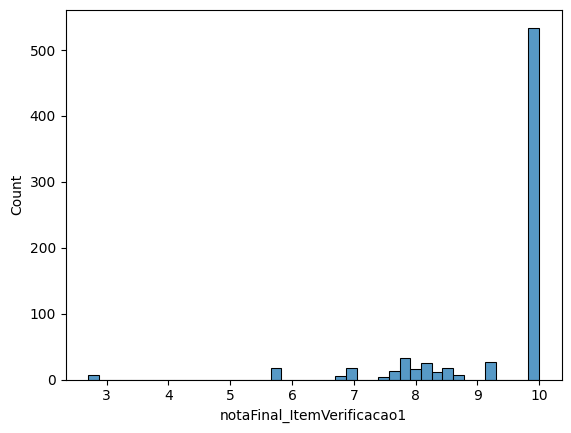

In [19]:
sns.histplot(qtPontes['notaFinal_ItemVerificacao1'])

In [20]:
print(len(qtPontes.query('notaFinal_ItemVerificacao1 < 4')['dsQuestaoAuxiliar1'].unique()))
qtPontes.query('notaFinal_ItemVerificacao1 < 4')['dsQuestaoAuxiliar1'].unique()

5


array(['A unidade educacional dispõe de biblioteca?',
       'A unidade educacional dispõe de sala de leitura?',
       'A unidade educacional dispõe de sala de recursos multifuncionais para Atendimento Educacional Especializado?',
       'A unidade educacional dispõe de laboratório de ciências?',
       'A unidade educacional dispõe de laboratório de informática?'],
      dtype=object)

In [21]:
print(len(qtPontes.query('notaFinal_ItemVerificacao1 > 9')['dsQuestaoAuxiliar1'].unique()))
qtPontes.query('notaFinal_ItemVerificacao1 > 9')['dsQuestaoAuxiliar1'].unique()

297


array(['O Plano Municipal de Educação está disponível para consulta no site oficial do Município?',
       'O Projeto Político-Pedagógico da unidade educacional foi elaborado ou atualizado envolvendo a participação da comunidade escolar?',
       'O Plano Municipal de Educação contempla meta de universalização da educação infantil para crianças de 4 a 5 anos de idade em consonância com a Meta 1 do Plano Nacional de Educação?',
       'O Projeto Político-Pedagógico da unidade educacional foi elaborado ou atualizado à luz das orientações trazidas pela Base Nacional Comum Curricular e pelo Referencial Curricular do Paraná: Princípios, Direitos e Orientações?',
       'A unidade educacional possui Projeto Político-Pedagógico?',
       'O relatório de monitoramento das metas do PME referente ao ano de 2021 está disponível no site oficial do Município?',
       'O Projeto Político-Pedagógico da unidade educacional contém Proposta Pedagógica Curricular para os anos iniciais do ensino fundamen

## Menor

In [7]:
guaraquecaba = df.query("municipio == 'GUARAQUECABA'")
guaraquecaba

,dsArea1,notaFinalPonderada1,dsQuestao1,dsQuestao_Abrev1,notafinal_Questao1,dsItemVerificacao1,dsItemVerificacao_Abrev1,notaFinal_ItemVerificacao1,dsQuestaoAuxiliar1,notaFinal_QuestaoAuxiliar,nmEntidadeVinculada,dsTipoResposta,id_municipio,municipio,anoAplicacao1
51805,Educação,4.05,O Município dispõe de instrumentos de planejam...,Instrumentos de planejamento,4.5,As unidades educacionais da rede municipal de ...,Projeto Político-Pedagógico,9.9,O Projeto Político-Pedagógico da unidade educa...,10.0,BRASILINA GOMES DA COSTA E R M EI EF,SIM,138,GUARAQUECABA,2022
51806,Educação,4.05,O Município dispõe de instrumentos de planejam...,Instrumentos de planejamento,4.5,As unidades educacionais da rede municipal de ...,Projeto Político-Pedagógico,9.9,O Projeto Político-Pedagógico da unidade educa...,10.0,VENCESLAU ARAUJO E R M EF,SIM,138,GUARAQUECABA,2022
51807,Educação,4.05,O Município dispõe de instrumentos de planejam...,Instrumentos de planejamento,4.5,As unidades educacionais da rede municipal de ...,Projeto Político-Pedagógico,9.9,O Projeto Político-Pedagógico da unidade educa...,10.0,MASSARAPOA E R M DE EF,SIM,138,GUARAQUECABA,2022
51808,Educação,4.05,O Município dispõe de instrumentos de planejam...,Instrumentos de planejamento,4.5,As unidades educacionais da rede municipal de ...,Projeto Político-Pedagógico,9.9,O Projeto Político-Pedagógico da unidade educa...,10.0,BERTIOGA E R M DE EF,SIM,138,GUARAQUECABA,2022
51809,Educação,4.05,O Município dispõe de instrumentos de planejam...,Instrumentos de planejamento,4.5,As unidades educacionais da rede municipal de ...,Projeto Político-Pedagógico,9.9,O Projeto Político-Pedagógico da unidade educa...,10.0,SERRA NEGRA E R M DE EF,SIM,138,GUARAQUECABA,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604085,Educação,3.93,As ações do Município contribuem para o atendi...,Serviço de alimentação escolar,4.7,As unidades educacionais da rede municipal de ...,Oferta da alimentação escolar,9.9,A unidade educacional oferece a quantidade nec...,10.0,BARBADO E R M DE EF,SIM,138,GUARAQUECABA,2023
604086,Educação,3.93,As ações do Município contribuem para o atendi...,Serviço de alimentação escolar,4.7,As unidades educacionais da rede municipal de ...,Oferta da alimentação escolar,9.9,As refeições oferecidas aos estudantes matricu...,9.6,MORATO E R M DE EF,SIM,138,GUARAQUECABA,2023
604087,Educação,3.93,As ações do Município contribuem para o atendi...,Serviço de alimentação escolar,4.7,O Município e as escolas municipais promovem a...,Educação alimentar e nutricional,7.4,A Educação Alimentar e Nutricional está inseri...,10.0,MORATO E R M DE EF,SIM,138,GUARAQUECABA,2023
604088,Educação,3.93,As ações do Município contribuem para o atendi...,Serviço de alimentação escolar,4.7,O Município e as escolas municipais promovem a...,Educação alimentar e nutricional,7.4,"No ano de 2023, foram realizadas oficinas prát...",2.5,MORATO E R M DE EF,NÃO,138,GUARAQUECABA,2023


In [9]:
guaraquecaba['nmEntidadeVinculada'].value_counts()

nmEntidadeVinculada
ANTONIO BARBOSA PINTO E M EI EF          228
SANTA TEREZINHA E R M EI EF              228
SERRA NEGRA E R M DE EF                  220
SIBUI E R M DE EF                        220
SALIM DO CARMO E R M EF                  220
BRASILINA GOMES DA COSTA E R M EI EF     217
ALICE DA SILVA SOBRINHO E R M EI EF      217
JOAO LUIZ DA SILVA JUNIOR E R M EI EF    217
JUVENAL XAVIER E R M EF                  215
UTINGA E R M DE EF                       215
IPANEMA E R M DE EF                      209
MORATO E R M DE EF                       209
BARBADO E R M DE EF                      209
BARRA DE ARARAPIRA E R M DA EF           209
GABRIEL RAMOS DA SILVA E R M EF          209
VENCESLAU ARAUJO E R M EF                209
MARIO DE MARIA E R M PE EF               209
TROMOMO E R M DE EF                      209
GUAPECUM E R M DE EF                     209
CANAL DE VARADOURO E R M EF              209
BERTIOGA E R M DE EF                     209
MASSARAPOA E R M DE EF             

<Axes: xlabel='notaFinal_ItemVerificacao1', ylabel='Count'>

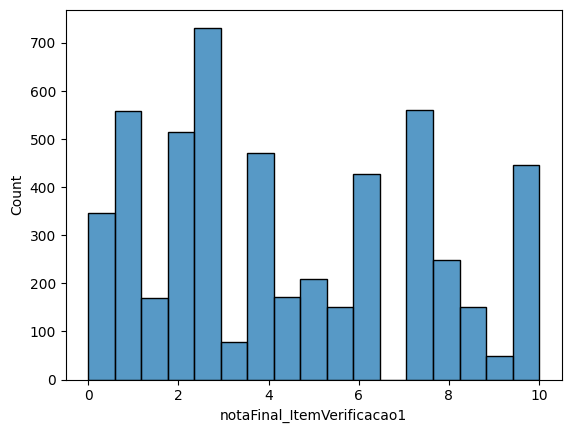

In [10]:
sns.histplot(guaraquecaba['notaFinal_ItemVerificacao1'])

In [15]:
print(len(guaraquecaba.query('notaFinal_ItemVerificacao1 < 4')['dsQuestaoAuxiliar1'].unique()))
guaraquecaba.query('notaFinal_ItemVerificacao1 < 4')['dsQuestaoAuxiliar1'].unique()

190


array(['O Município define o período de avaliação do Plano Municipal de Educação (na própria lei do plano ou por meio de outro ato oficial)?',
       'O relatório de monitoramento das metas do PME referente ao ano de 2021 contempla o monitoramento da situação da meta de universalização da educação infantil para crianças de 4 a 5 anos de idade?',
       'O relatório relativo ao último processo de avaliação realizado contém recomendações para redirecionamentos e atualizações do Plano Municipal de Educação?',
       'O Município define as instâncias responsáveis pelo processo de monitoramento e avaliação do Plano Municipal de Educação (na própria lei do plano ou por meio de outro ato oficial)?',
       'O relatório de monitoramento das metas do PME referente ao ano de 2021 está disponível no site oficial do Município?',
       'O relatório de avaliação do Plano Municipal de Educação está disponível no site oficial do Município?',
       'O relatório de monitoramento das metas do PME refer

In [16]:
print(len(guaraquecaba.query('notaFinal_ItemVerificacao1 > 9')['dsQuestaoAuxiliar1'].unique()))
guaraquecaba.query('notaFinal_ItemVerificacao1 > 9')['dsQuestaoAuxiliar1'].unique()

21


array(['O Projeto Político-Pedagógico da unidade educacional contém Proposta Pedagógica Curricular para os anos iniciais do ensino fundamental definida e organizada de modo a explicitar e garantir os direitos de aprendizagem especificados na Base Nacional Comum Curricular, no Referencial Curricular do Paraná e na proposta curricular da rede de ensino?',
       'O Projeto Político-Pedagógico da unidade educacional contém Proposta Pedagógica Curricular para os anos iniciais do ensino fundamental que estabeleça parte diversificada definida com base nas características da sociedade local, da cultura, da economia e dos educandos?',
       'O Projeto Político-Pedagógico da unidade educacional foi elaborado ou atualizado à luz das orientações trazidas pela Base Nacional Comum Curricular e pelo Referencial Curricular do Paraná: Princípios, Direitos e Orientações?',
       'O Projeto Político-Pedagógico da unidade educacional foi elaborado ou atualizado envolvendo a participação da comunidade e